<a href="https://www.kaggle.com/code/lalit7881/youtube-shorts-analytics?scriptVersionId=304956923" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/youtube-shorts-engagement-and-growth-velocity/YouTube_Shorts_Engagement_and_Growth_Velocity.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/youtube-shorts-engagement-and-growth-velocity/YouTube_Shorts_Engagement_and_Growth_Velocity.csv")

In [3]:
df.head()

,Video_ID,Title,Channel_Name,Views,Likes,Comments,Age_In_Days,Engagement_Rate_%,Views_Per_Day,Video_URL,Description_Length
0,XcTzxw9JAnM,How YouTube Wants You to Make Shorts,Think Media,23945,862,120,201,4.1011,119.13,https://www.youtube.com/watch?v=XcTzxw9JAnM,4546
1,fKIqusb14E0,Most Viewed YouTube Shorts! *VIRAL*,Stay Wild Reacts,16456884,129000,4863,342,0.8134,48119.54,https://www.youtube.com/watch?v=fKIqusb14E0,217
2,E_goHQxVmb4,How to Make Money with YouTube Shorts (Full Gu...,Alex Christian,326589,10000,938,270,3.3492,1209.59,https://www.youtube.com/watch?v=E_goHQxVmb4,1505
3,1EAus8qZeyM,How to Make a YouTube Short - Complete Beginne...,vidIQ,1778131,25000,2261,989,1.5331,1797.91,https://www.youtube.com/watch?v=1EAus8qZeyM,1001
4,oCxrIij2iXo,*NEW* World’s MOST Viewed YouTube Shorts!,MoreAliA,1307628,7500,443,85,0.6074,15383.86,https://www.youtube.com/watch?v=oCxrIij2iXo,1253


In [4]:
df.columns

Index(['Video_ID', 'Title', 'Channel_Name', 'Views', 'Likes', 'Comments',
       'Age_In_Days', 'Engagement_Rate_%', 'Views_Per_Day', 'Video_URL',
       'Description_Length'],
      dtype='object')

In [5]:
# Step 3: Inspect the dataset
print(df.head())       # First 5 rows
print(df.tail())       # Last 5 rows
print(df.info())       # Data types, non-null counts
print(df.describe())   # Statistical summary of numeric columns
print(df.shape)        # Number of rows and columns
print(df.columns)      # Column names
print(df.isnull().sum())  # Count missing values per column

      Video_ID                                              Title  \
0  XcTzxw9JAnM               How YouTube Wants You to Make Shorts   
1  fKIqusb14E0                Most Viewed YouTube Shorts! *VIRAL*   
2  E_goHQxVmb4  How to Make Money with YouTube Shorts (Full Gu...   
3  1EAus8qZeyM  How to Make a YouTube Short - Complete Beginne...   
4  oCxrIij2iXo          *NEW* World’s MOST Viewed YouTube Shorts!   

       Channel_Name     Views   Likes  Comments  Age_In_Days  \
0       Think Media     23945     862       120          201   
1  Stay Wild Reacts  16456884  129000      4863          342   
2    Alex Christian    326589   10000       938          270   
3             vidIQ   1778131   25000      2261          989   
4          MoreAliA   1307628    7500       443           85   

   Engagement_Rate_%  Views_Per_Day  \
0             4.1011         119.13   
1             0.8134       48119.54   
2             3.3492        1209.59   
3             1.5331        1797.91   
4    

In [6]:
print(df['Views'].head())  # Single column
print(df[['Views','Likes','Comments']].head())  # Multiple columns

0       23945
1    16456884
2      326589
3     1778131
4     1307628
Name: Views, dtype: int64
      Views   Likes  Comments
0     23945     862       120
1  16456884  129000      4863
2    326589   10000       938
3   1778131   25000      2261
4   1307628    7500       443


In [7]:
# Step 5: Filtering rows
high_engagement = df[df['Engagement_Rate_%'] > 10]  # Example filter
print(high_engagement.head())

        Video_ID                                              Title  \
64   ZjIko5ZiDZ4                       YouTube Shorts : Brain Drain   
92   _u4POCdoBlE  Gulab upada ke jabardast colour 💥8816826455#tr...   
119  zf7T9FVR2NA  Bread & Barbecue Sauce Was My Poverty Meal — W...   
170  -dGWxox788A  😲Short डालते ही 501% Viral 📈| How to viral sho...   
214  Zc3ac7EWdbE  How to Escape  0, 15K and 30K View Jail - On Y...   

         Channel_Name   Views  Likes  Comments  Age_In_Days  \
64          Flazefire  189619  20000      2207           17   
92   Poonia  Boutique     303     53         4            1   
119     Tom Powell Jr    3809    535       109            1   
170      Yt Aman Tech   60111   3200      3157           18   
214           Creatie  406412  45000      9053          220   

     Engagement_Rate_%  Views_Per_Day  \
64             11.7114       11154.06   
92             18.8119         303.00   
119            16.9073        3809.00   
170            10.5754        

In [8]:
# Step 6: Sorting data
df_sorted = df.sort_values(by='Views', ascending=False)
print(df_sorted.head())

        Video_ID                                              Title  \
249  9FDVvWR91ww                              Sister love 💕 #shorts   
275  y8kneKeNyCI  Belly Button Song Dance! Learn about the Body!...   
235  ycyryfTLDdY  Top New Funniest Comedy Video 😂 Most Watch Vir...   
264  EqQz2rHKHxE                 Monster drinks boba tea 🧋😂 #shorts   
265  UUb68mu2G1M                               Legendary😂🇺🇬 #shorts   

                   Channel_Name       Views     Likes  Comments  Age_In_Days  \
249           Sierra & Rhia FAM  2138155337  22000000         0          877   
275  Cocomelon - Nursery Rhymes  1262062063  12000000         0         1081   
235                   MY FAMILY   724866455   1700000     13879         1447   
264                     Yoeslan   687089438   5400000      4837          309   
265               Noel Robinson   568885082  12000000     58089          778   

     Engagement_Rate_%  Views_Per_Day  \
249             1.0289     2438033.45   
275       

In [9]:
# Step 7: Adding new columns
df['Like_Ratio'] = df['Likes'] / df['Views']  # Likes per view
df['Comment_Ratio'] = df['Comments'] / df['Views']  # Comments per view
print(df[['Views','Likes','Comments','Like_Ratio','Comment_Ratio']].head())

      Views   Likes  Comments  Like_Ratio  Comment_Ratio
0     23945     862       120    0.035999       0.005011
1  16456884  129000      4863    0.007839       0.000295
2    326589   10000       938    0.030620       0.002872
3   1778131   25000      2261    0.014060       0.001272
4   1307628    7500       443    0.005736       0.000339


In [10]:
# Step 8: Renaming columns
df.rename(columns={'Age_In_Days':'AgeDays','Engagement_Rate_%':'EngagementRate'}, inplace=True)

In [11]:
# Fill numeric columns with median
numeric_cols = ['Views','Likes','Comments','AgeDays','EngagementRate','Views_Per_Day','Description_Length']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [12]:
# Fill string columns with 'Unknown'
string_cols = ['Video_ID','Title','Channel_Name','Video_URL']
for col in string_cols:
    df[col].fillna('Unknown', inplace=True)

In [13]:
# Step 10: Aggregations
avg_engagement_by_channel = df.groupby('Channel_Name')['EngagementRate'].mean().sort_values(ascending=False)
print(avg_engagement_by_channel.head(10))

Channel_Name
Poonia  Boutique      18.8119
Tom Powell Jr         16.9073
The Abhay Dynasty     14.0059
Creatie               13.3001
Flazefire             11.7114
jacobweeby             9.4741
RunnyIA                8.7753
moneyboymax            8.2561
Balarke                7.8335
Los Angeles Rams       7.7930
Name: EngagementRate, dtype: float64


In [14]:
# Step 11: Value counts
print(df['Channel_Name'].value_counts().head(10))  # Top channels by number of videos

Channel_Name
LiDiRo Reagiert                         14
Sejal Gaba                              12
Abdullah Tariq Khan                     10
MAGNETFILM                               9
Jonathan Joly                            8
BETER BÖCÜK                              7
JUSTJULES💖                               7
MoreAliA                                 7
Misti Happy Lifestyle Games & Shorts     6
ROCK SQUAD                               6
Name: count, dtype: int64


In [15]:
# Step 12: Apply functions
df['Engagement_Category'] = df['EngagementRate'].apply(lambda x: 'High' if x>10 else 'Low')
print(df[['EngagementRate','Engagement_Category']].head())

   EngagementRate Engagement_Category
0          4.1011                 Low
1          0.8134                 Low
2          3.3492                 Low
3          1.5331                 Low
4          0.6074                 Low


In [16]:
# Step 13: Pivot tables
pivot = df.pivot_table(values='Views', index='Channel_Name', columns='Engagement_Category', aggfunc='mean')
print(pivot.head())

Engagement_Category  High         Low
Channel_Name                         
101 FAKT              NaN  19218556.0
7-ElevenZ             NaN    628316.0
972film               NaN     28048.0
ABC                   NaN     29227.0
ACMofficial           NaN    383154.0


In [17]:
df.drop(['Video_URL'], axis=1, inplace=True)


In [18]:
corr = df[['Views','Likes','Comments','AgeDays','EngagementRate','Views_Per_Day','Description_Length']].corr()
print(corr)

                       Views     Likes  Comments   AgeDays  EngagementRate  \
Views               1.000000  0.918878  0.111725  0.113996       -0.104484   
Likes               0.918878  1.000000  0.237071  0.105400       -0.022724   
Comments            0.111725  0.237071  1.000000  0.099738        0.119011   
AgeDays             0.113996  0.105400  0.099738  1.000000       -0.161632   
EngagementRate     -0.104484 -0.022724  0.119011 -0.161632        1.000000   
Views_Per_Day       0.241587  0.208331 -0.006207 -0.134185       -0.088183   
Description_Length -0.045535 -0.074470  0.030381  0.089573        0.214603   

                    Views_Per_Day  Description_Length  
Views                    0.241587           -0.045535  
Likes                    0.208331           -0.074470  
Comments                -0.006207            0.030381  
AgeDays                 -0.134185            0.089573  
EngagementRate          -0.088183            0.214603  
Views_Per_Day            1.000000      

## EDA

In [19]:
# Rename for simplicity
df.rename(columns={'Age_In_Days':'AgeDays','Engagement_Rate_%':'EngagementRate'}, inplace=True)


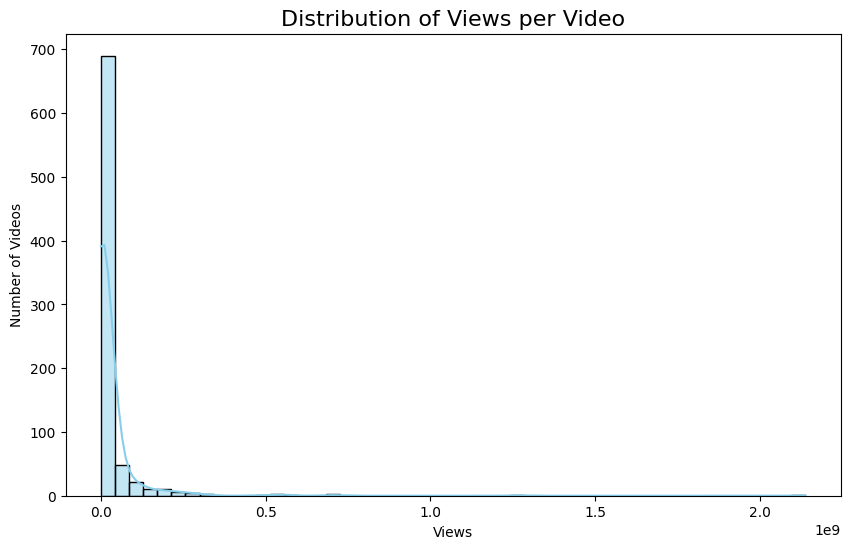

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(df['Views'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Views per Video", fontsize=16)
plt.xlabel("Views")
plt.ylabel("Number of Videos")
plt.show()

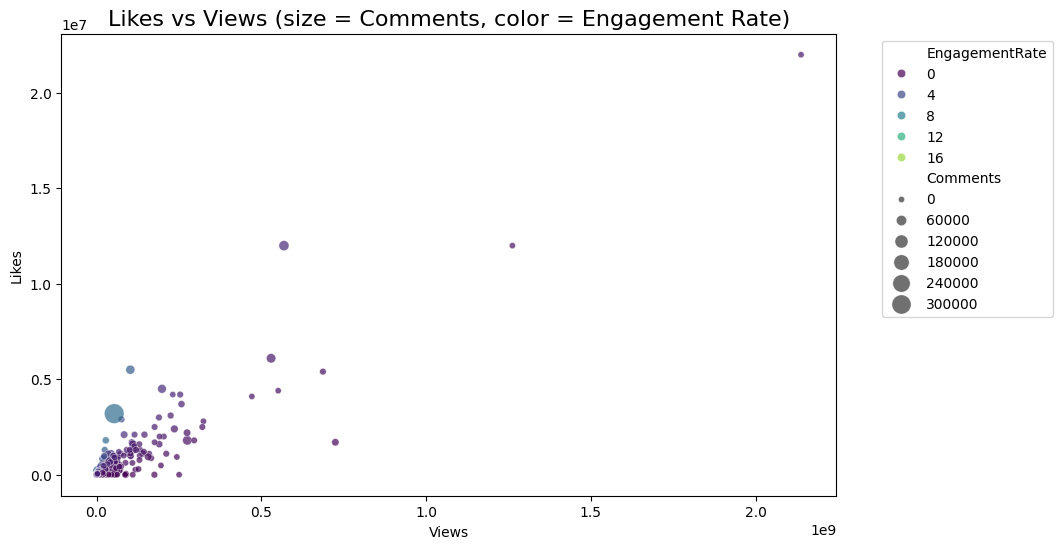

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Views', y='Likes', hue='EngagementRate', palette='viridis', size='Comments', sizes=(20,200), alpha=0.7, data=df)
plt.title("Likes vs Views (size = Comments, color = Engagement Rate)", fontsize=16)
plt.xlabel("Views")
plt.ylabel("Likes")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

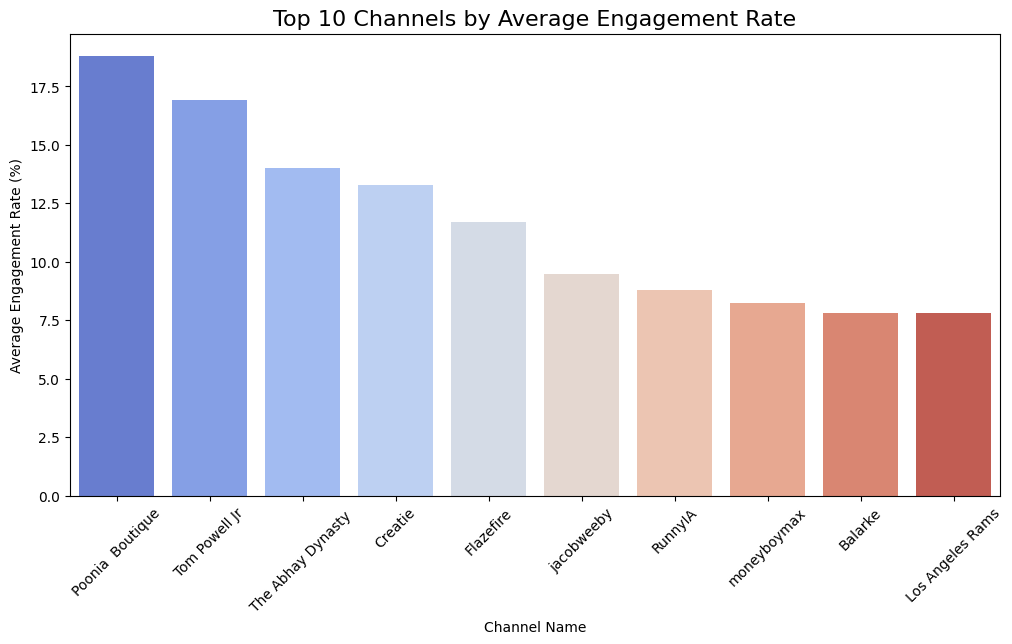

In [22]:
avg_engagement = df.groupby('Channel_Name')['EngagementRate'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=avg_engagement.index, y=avg_engagement.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Top 10 Channels by Average Engagement Rate", fontsize=16)
plt.xlabel("Channel Name")
plt.ylabel("Average Engagement Rate (%)")
plt.show()

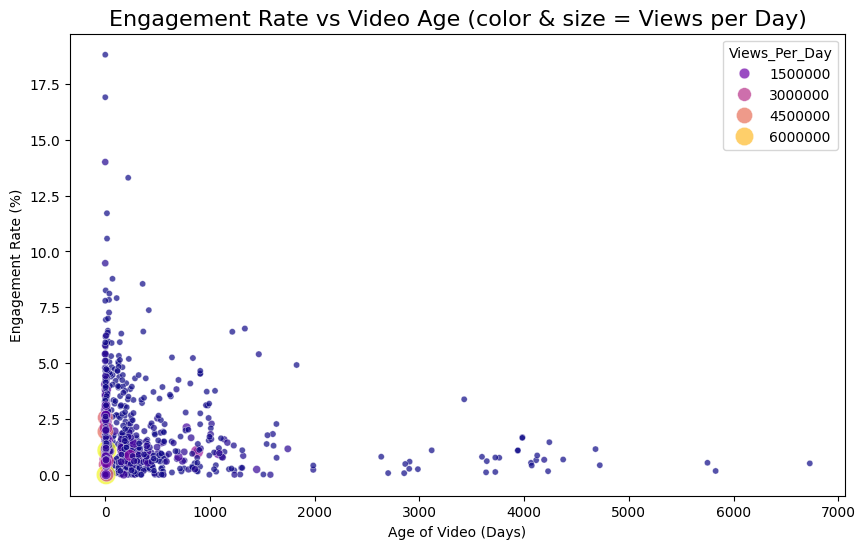

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='AgeDays', y='EngagementRate', hue='Views_Per_Day', palette='plasma', size='Views_Per_Day', sizes=(20,200), data=df, alpha=0.7)
plt.title("Engagement Rate vs Video Age (color & size = Views per Day)", fontsize=16)
plt.xlabel("Age of Video (Days)")
plt.ylabel("Engagement Rate (%)")
plt.show()

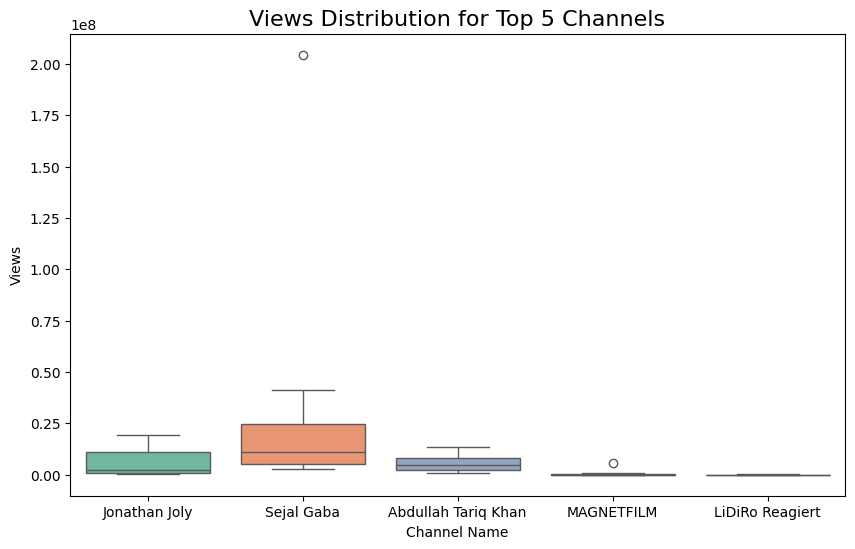

In [24]:
top_channels = df['Channel_Name'].value_counts().head(5).index
plt.figure(figsize=(10,6))
sns.boxplot(x='Channel_Name', y='Views', data=df[df['Channel_Name'].isin(top_channels)], palette='Set2')
plt.title("Views Distribution for Top 5 Channels", fontsize=16)
plt.xlabel("Channel Name")
plt.ylabel("Views")
plt.show()

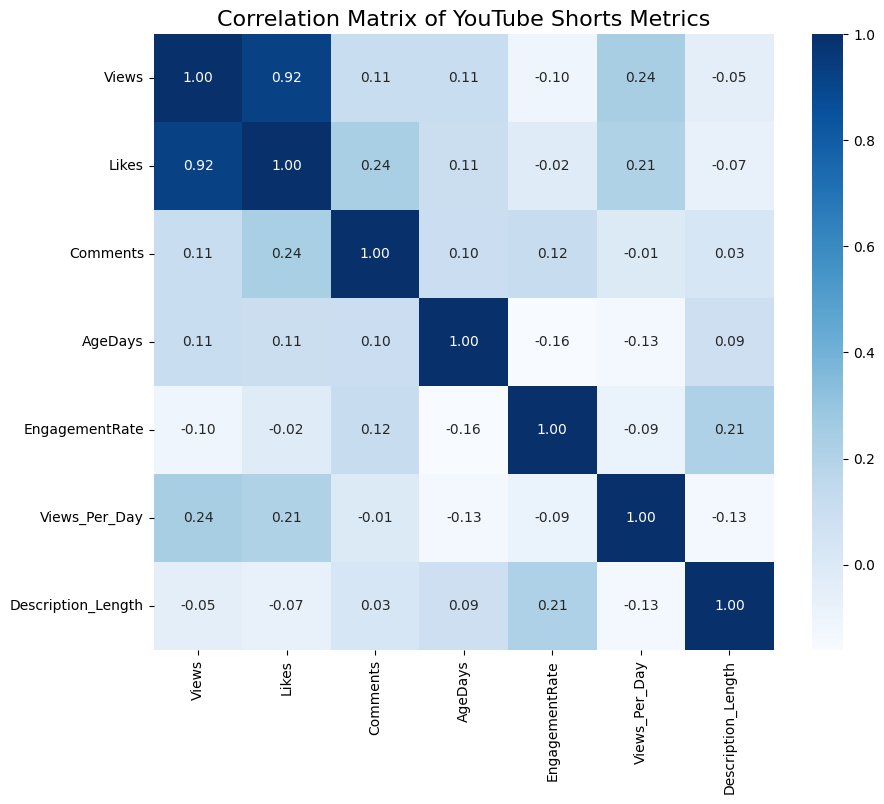

In [25]:
plt.figure(figsize=(10,8))
corr = df[['Views','Likes','Comments','AgeDays','EngagementRate','Views_Per_Day','Description_Length']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Matrix of YouTube Shorts Metrics", fontsize=16)
plt.show()

## Feature engineering

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

In [27]:
df.rename(columns={'Age_In_Days':'AgeDays','Engagement_Rate_%':'EngagementRate'}, inplace=True)

In [28]:
numeric_cols = ['Views','Likes','Comments','AgeDays','EngagementRate','Views_Per_Day',
                'Description_Length','Like_Ratio','Comment_Ratio']
string_cols = ['Video_ID','Title','Channel_Name','Engagement_Category']

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in string_cols:
    df[col].fillna('Unknown', inplace=True)

In [29]:
categorical_cols = ['Channel_Name','Engagement_Category']
for col in categorical_cols:
    df[col] = df[col].astype(str)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [30]:
df['EngagementTarget'] = df['Engagement_Category'] 

In [31]:
features = ['Views','Likes','Comments','AgeDays','Views_Per_Day','Description_Length',
            'Like_Ratio','Comment_Ratio','Channel_Name']
X = df[features]
y = df['EngagementTarget']

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


In [34]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

Logistic Regression Accuracy: 99.38%
Random Forest Accuracy: 99.38%
XGBoost Accuracy: 99.38%


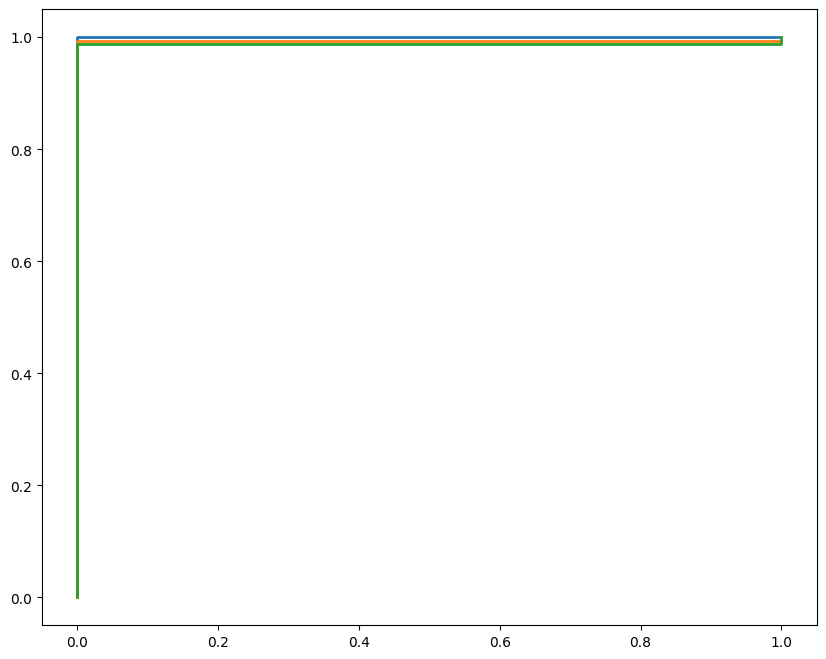

In [35]:
plt.figure(figsize=(10,8))
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]  # probability for ROC
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc*100:.2f}%")
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

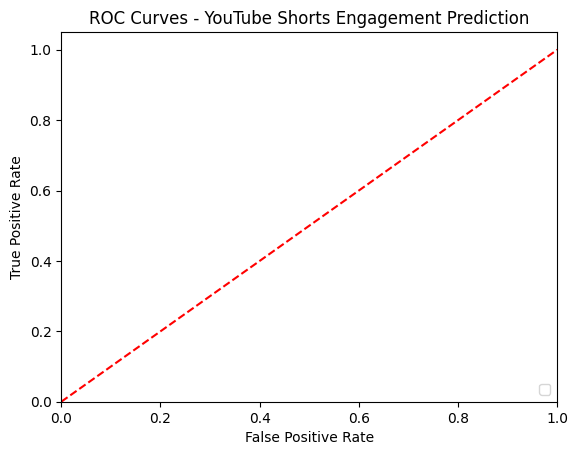

In [36]:
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - YouTube Shorts Engagement Prediction')
plt.legend(loc='lower right')
plt.show()

## Thank you..pls upvote!!!!!!!!!!!!!